# ShopSmart Purchase Prediction Using Decision Tree

## Problem Statement

ShopSmart wants to predict whether an online visitor will complete a purchase based on their browsing behaviour during a website session.

The dataset contains information such as:

- Number of administrative pages visited
- Time spent on administrative pages
- Number of informational pages visited
- Number of product-related pages visited
- Time spent on product-related pages
- Bounce rate
- Exit rate
- Page value
- Month
- Operating system
- Browser
- Region
- Traffic type
- Visitor type
- Weekend

The target variable is `Revenue`, which indicates whether the visitor completed a purchase.

This is a supervised machine learning problem because the target outcome is already available in the historical data.

Since `Revenue` has two possible values, True and False, this is a binary classification problem.

The required machine learning algorithm is a Decision Tree Classifier.

Because the target classes are imbalanced, F1 Score will be used as the primary evaluation metric.

The assignment benchmark is:

F1 Score >= 0.55

The assignment also requires pruning the Decision Tree to reduce overfitting and improve generalization.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load Dataset

df = pd.read_csv("shop_smart_ecommerce_data.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
# Understand Dataset
df.shape
df.sample(5, random_state=42)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [6]:
#df.isnull().sum()

missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [7]:
# check duplication
df.duplicated().sum()

# for inspection of Duplication
df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
).head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


In [8]:
# to remove duplicate rows
df = df.drop_duplicates().copy()
df.shape

(12205, 18)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# lets see Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12205.0,NaN,NaN,NaN,2.338878,3.330436,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12205.0,NaN,NaN,NaN,81.646331,177.491845,0.0,0.0,9.0,94.7,3398.75
Informational,12205.0,NaN,NaN,NaN,0.508726,1.275617,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12205.0,NaN,NaN,NaN,34.825454,141.424807,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12205.0,NaN,NaN,NaN,32.045637,44.593649,0.0,8.0,18.0,38.0,705.0
ProductRelated_Duration,12205.0,NaN,NaN,NaN,1206.982457,1919.6014,0.0,193.0,608.942857,1477.154762,63973.52223
BounceRates,12205.0,NaN,NaN,NaN,0.02037,0.045255,0.0,0.0,0.002899,0.016667,0.2
ExitRates,12205.0,NaN,NaN,NaN,0.041466,0.046163,0.0,0.014231,0.025,0.048529,0.2
PageValues,12205.0,NaN,NaN,NaN,5.949574,18.653671,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12205.0,NaN,NaN,NaN,0.061942,0.199666,0.0,0.0,0.0,0.0,1.0


In [11]:
# lets understand the target values
df["Revenue"].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [12]:
df["Revenue"].value_counts(normalize=True) * 100

Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64

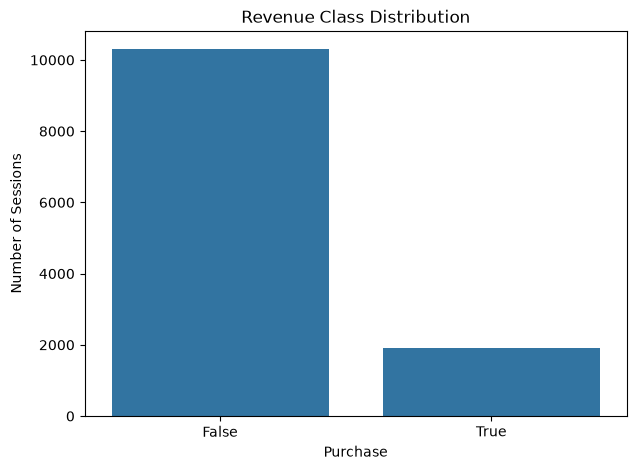

In [13]:
# Visual Class imbalance
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Revenue")

plt.title("Revenue Class Distribution")
plt.xlabel("Purchase")
plt.ylabel("Number of Sessions")

plt.show()

## Why F1 Score Instead of Accuracy?

The target variable is imbalanced:

- No Purchase = approximately 84.53%
- Purchase = approximately 15.47%

A model that predicts "No Purchase" for almost every visitor can achieve high accuracy while performing poorly at identifying actual purchasers.

Therefore, accuracy is not sufficient for this problem.

The assignment requires F1 Score because F1 balances Precision and Recall:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

The target benchmark is:

F1 >= 0.55

In [14]:
# Analyze Visitor Type

pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
) * 100

Revenue,False,True
VisitorType,,
New_Visitor,75.073833,24.926167
Other,80.246914,19.753086
Returning_Visitor,85.907391,14.092609


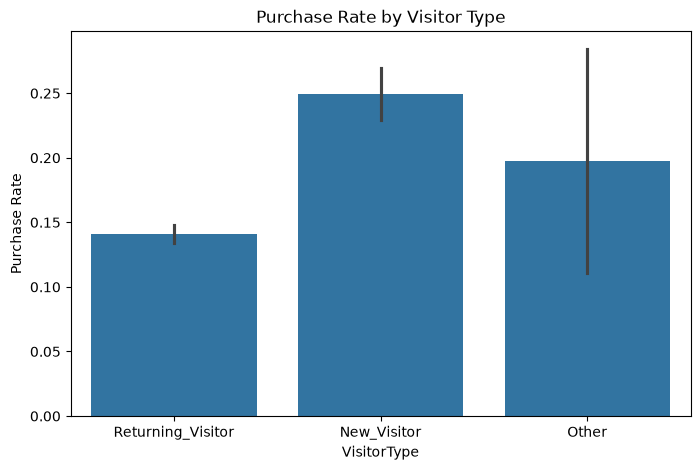

In [15]:
# Visualize visitor type
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="VisitorType",
    y="Revenue"
)

plt.title("Purchase Rate by Visitor Type")
plt.ylabel("Purchase Rate")

plt.show()

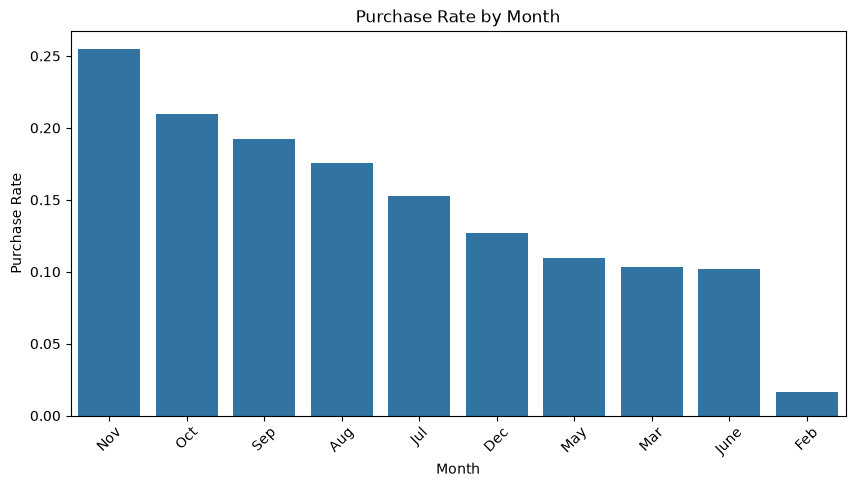

In [16]:
# lets Anayze month
month_revenue = (
    df.groupby("Month")["Revenue"].mean().sort_values(ascending=False)
)

month_revenue

# visualize
plt.figure(figsize=(10, 5))

sns.barplot(
    x=month_revenue.index,
    y=month_revenue.values
)

plt.title("Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Purchase Rate")

plt.xticks(rotation=45)

plt.show()

In [17]:
# Weekend Analysis
pd.crosstab(
    df["Weekend"],
    df["Revenue"],
    normalize="index"
) * 100

Revenue,False,True
Weekend,,
False,84.924032,15.075968
True,82.546345,17.453655


In [20]:
# identify numericals and categorical features

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorica Features")
print(categorical_features)

Numerical Features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorica Features
['Month', 'VisitorType', 'Weekend', 'Revenue']


In [22]:
# As Revenue is the target feature so we have to remove from feature list
categorical_features.remove("Revenue")

In [23]:
print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Categorical Features: ['Month', 'VisitorType', 'Weekend']


# Now investigate the numerical browsing-behaviour features. We want to understand their distributions and identify highly skewed or unusual values before modeling.

In [26]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


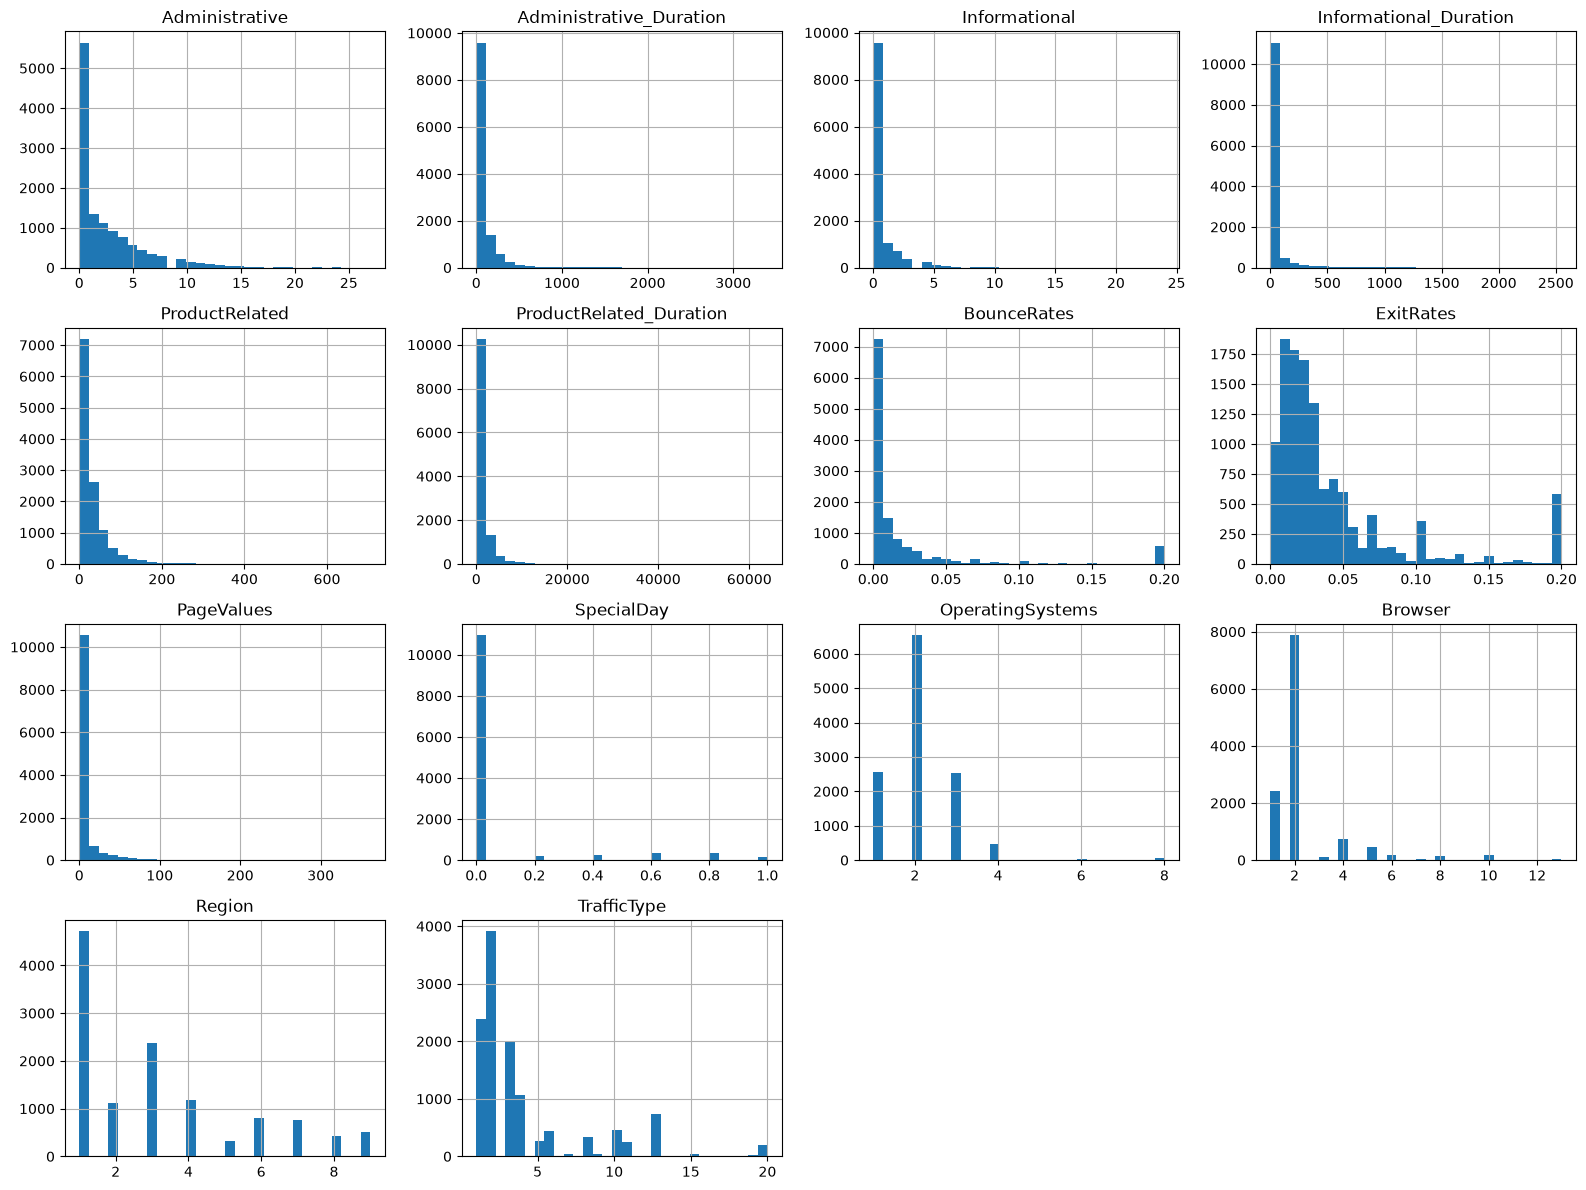

In [27]:
# Visualize the numerical variables to understand their distributions.
df[numeric_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

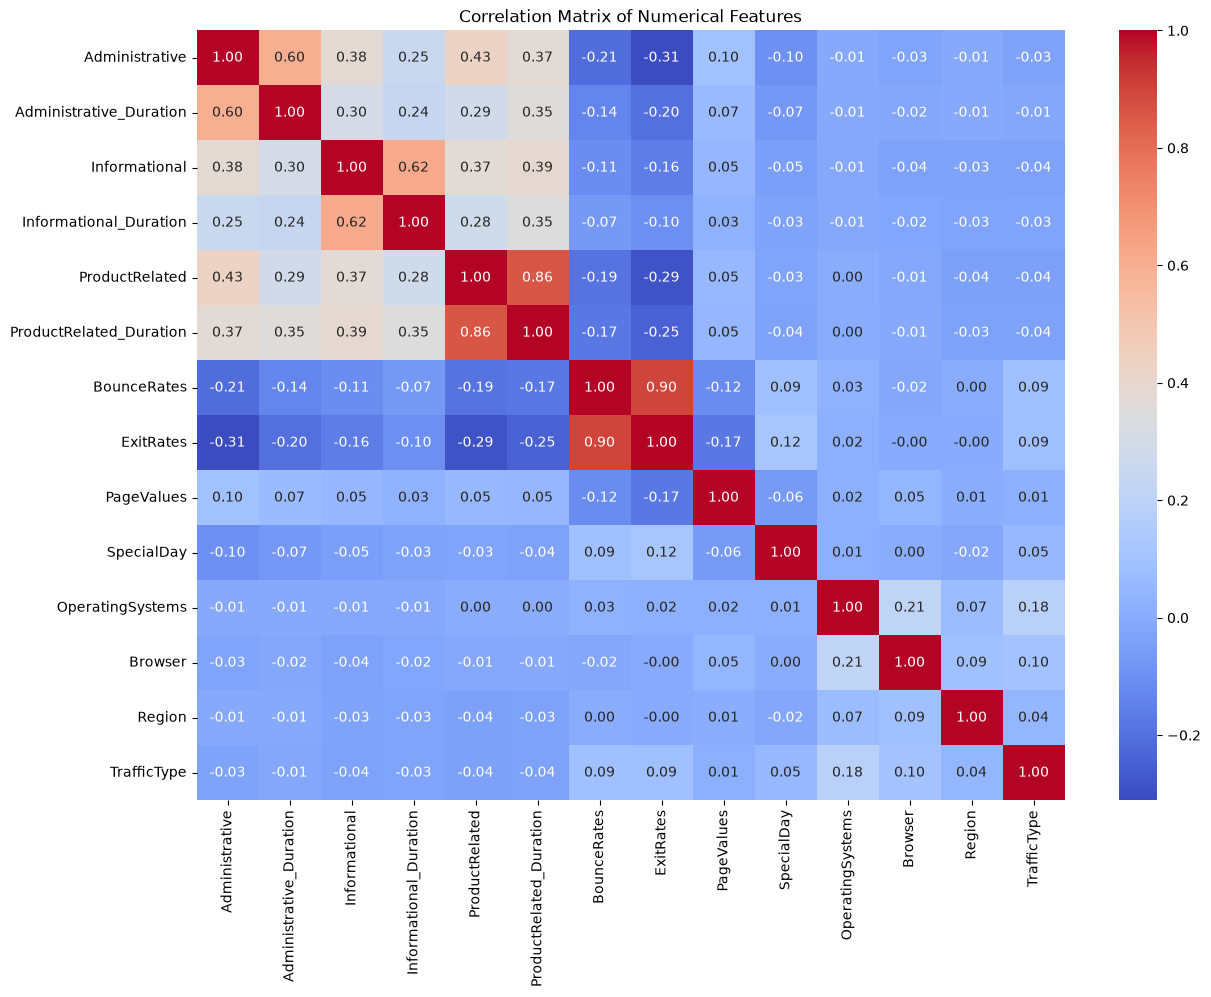

In [28]:
# Check relationships between numerical features.
# This helps us understand whether some variables contain similar information.
plt.figure(figsize=(14, 10))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()